In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles

from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.svm import OneClassSVM

In [2]:
%pip install -q ipywidgets

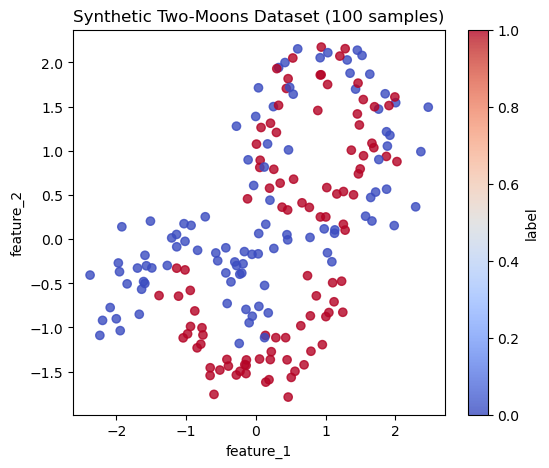

In [3]:
# generate a 2D, 2-class dataset with moons and circles
NOISE = 0.2
SAMPLE_SIZE = 200
SEED = 2
OFFSET = 1

# calculations
n_moons = SAMPLE_SIZE // 2
n_circles = SAMPLE_SIZE - n_moons

# first cluster

X1, y1 = make_moons(
    n_samples=n_moons,
    noise=NOISE,
    random_state=SEED,
)
X1[:, 0] -= OFFSET
X1[:, 1] -= OFFSET


# second cluster
X2, y2 = make_circles(
    n_samples=n_circles,
    noise=NOISE,
    random_state=SEED+1,
)
X2[:, 0] += OFFSET
X2[:, 1] += OFFSET

# combine
X = np.vstack([X1, X2])
y = np.concatenate([y1, y2])
df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
df["label"] = y

# visualize
plt.figure(figsize=(6, 5))
scatter = plt.scatter(df["feature_1"], df["feature_2"], c=df["label"], cmap="coolwarm", alpha=0.8)
plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("Synthetic Two-Moons Dataset (100 samples)")
plt.colorbar(scatter, label="label");

In [4]:
# Train the red vs. blue classifier
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42)),
])

svm_param_grid = {
    "svm__C": [0.1, 0.5, 1, 5, 10, 50, 100],
    "svm__gamma": ["scale", 0.1, 0.5, 1, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_cv = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
)

svm_cv.fit(X, y)
best_params = svm_cv.best_params_
svm_best = svm_cv.best_estimator_

print(
    f"Best Hyperparameters: "
    f"C = {best_params['svm__C']}, "
    f"gamma = {best_params['svm__gamma']}"
)
print(f"Best CV ROC AUC: {svm_cv.best_score_:.3f}")

Best Hyperparameters: C = 50, gamma = 1
Best CV ROC AUC: 0.910


Text(0, 0.5, 'True Positive Rate')

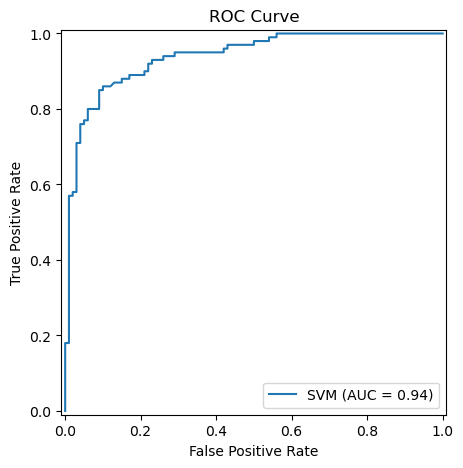

In [5]:
# ROC Curve
plt.figure(figsize=(6, 5))
ax = plt.gca()
RocCurveDisplay.from_estimator(svm_best, X, y, ax=ax, name="SVM")
ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

In [6]:
# Train the anomaly detector

# nu=0.05 means ~5% of data are marked as outliers/anomalies
oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.05)
oc_svm.fit(X)

# Decision function: positive = inlier, negative = outlier
inlier_pred = oc_svm.predict(X)
decision_scores = oc_svm.decision_function(X)

# metrics
n_outliers = np.sum(inlier_pred == -1)
outlier_rate = n_outliers / len(X)
print(f"Outliers: {n_outliers}/{len(X)} ({outlier_rate:.1%})")

Outliers: 8/200 (4.0%)


In [7]:
# Interactive Contour and Decision Boundary Plot
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import ipywidgets as widgets
from IPython.display import display

combined_cmap = ListedColormap(["#3b82f6", "#ef4444", "#9ca3af"])

anomaly_threshold_slider = widgets.FloatSlider(
    value=0.0,
    min=np.floor((decision_scores.min() - 1) * 100) / 100, # ensure we can snap to 0
    max=np.ceil((decision_scores.max() + 0.01) * 100) / 100,
    step=0.01,
    description="Anomal Threshold:",
    readout_format=".3f",
    continuous_update=True,
    layout=widgets.Layout(width="600px"),
)
anomaly_threshold_slider.style = {
    "description_width": "120px"
}

decision_threshold_slider = widgets.FloatSlider(
    value=0.5,
    min=0.0,
    max=1.0,
    step=0.01,
    description="Decision Threshold:",
    readout_format=".2f",
    continuous_update=True,
    layout=widgets.Layout(width="600px"),
)
decision_threshold_slider.style = {
    "description_width": "120px"
}

view_toggle = widgets.ToggleButtons(
    options=[
        "Anomaly Contour",
        "Classification Contour",
        "Decision Boundary",
    ],
    value="Decision Boundary",
    description="View:",
)

x0_min, x0_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
x1_min, x1_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
xx0, xx1 = np.meshgrid(
    np.linspace(x0_min, x0_max, 400),
    np.linspace(x1_min, x1_max, 400),
)
grid = np.c_[xx0.ravel(), xx1.ravel()]

class_prob_grid = svm_best.predict_proba(grid)[:, 1]
anomaly_score_grid = oc_svm.decision_function(grid)
class_prob_points = svm_best.predict_proba(X)[:, 1]

combined_stats = widgets.HTML()

def update_combined_plot(oc_threshold, decision_threshold, view):
    class_pred_grid = (class_prob_grid >= decision_threshold).astype(int)
    class_pred_points = (class_prob_points >= decision_threshold).astype(int)

    is_anomaly_grid = anomaly_score_grid < oc_threshold
    is_anomaly_points = decision_scores < oc_threshold

    combined_grid = np.where(is_anomaly_grid, 2, class_pred_grid).reshape(xx0.shape)
    combined_point_pred = np.where(is_anomaly_points, 2, class_pred_points)

    count_actual_blue_pred_blue = int(np.sum((y == 0) & (combined_point_pred == 0)))
    count_actual_blue_pred_red = int(np.sum((y == 0) & (combined_point_pred == 1)))
    count_actual_blue_anomaly = int(np.sum((y == 0) & (combined_point_pred == 2)))

    count_actual_red_pred_blue = int(np.sum((y == 1) & (combined_point_pred == 0)))
    count_actual_red_pred_red = int(np.sum((y == 1) & (combined_point_pred == 1)))
    count_actual_red_anomaly = int(np.sum((y == 1) & (combined_point_pred == 2)))

    non_anomaly = combined_point_pred != 2
    if np.any(non_anomaly):
        accuracy = np.mean(combined_point_pred[non_anomaly] == y[non_anomaly])
    else:
        accuracy = np.nan

    actual_red = y == 1
    actual_blue = y == 0

    red_non_anomaly = actual_red & non_anomaly
    blue_non_anomaly = actual_blue & non_anomaly

    sensitivity = (
        np.sum((combined_point_pred == 1) & actual_red) / np.sum(red_non_anomaly)
        if np.sum(red_non_anomaly) > 0
        else np.nan
    )
    specificity = (
        np.sum((combined_point_pred == 0) & actual_blue) / np.sum(blue_non_anomaly)
        if np.sum(blue_non_anomaly) > 0
        else np.nan
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    if view == "Anomaly Contour":
        ax.contourf(
            xx0,
            xx1,
            anomaly_score_grid.reshape(xx0.shape),
            levels=20,
            cmap="RdYlGn",
            alpha=0.3,
        )
        ax.contour(
            xx0,
            xx1,
            anomaly_score_grid.reshape(xx0.shape),
            levels=[oc_threshold],
            colors="black",
            linewidths=1,
        )

    elif view == "Classification Contour":
        ax.contourf(
            xx0,
            xx1,
            class_prob_grid.reshape(xx0.shape),
            levels=np.linspace(0, 1, 21),
            cmap="coolwarm",
            alpha=0.3,
        )
        ax.contour(
            xx0,
            xx1,
            class_prob_grid.reshape(xx0.shape),
            levels=[decision_threshold],
            colors="black",
            linewidths=1,
        )

    else:
        ax.contourf(
            xx0,
            xx1,
            combined_grid,
            levels=[-0.5, 0.5, 1.5, 2.5],
            cmap=combined_cmap,
            alpha=0.28,
        )
        ax.contour(
            xx0,
            xx1,
            anomaly_score_grid.reshape(xx0.shape),
            levels=[oc_threshold],
            colors="black",
            linewidths=1,
        )

    for actual_label, facecolor in [(0, "#3b82f6"), (1, "#ef4444")]:
        idx = (y == actual_label) & (~is_anomaly_points)
        edgecolors = np.where(class_pred_points[idx] == 0, "#3b82f6", "#ef4444")

        ax.scatter(
            X[idx, 0],
            X[idx, 1],
            c=facecolor,
            edgecolor=edgecolors,
            s=60,
            alpha=0.85,
            linewidths=1,
        )

    anomaly_idx = is_anomaly_points
    if np.any(anomaly_idx):
        ax.scatter(
            X[anomaly_idx, 0],
            X[anomaly_idx, 1],
            c=np.where(y[anomaly_idx] == 0, "#3b82f6", "#ef4444"),
            edgecolor="black",
            marker="o",
            s=70,
            alpha=0.85,
            linewidths=1,
        )
        ax.scatter(
            X[anomaly_idx, 0],
            X[anomaly_idx, 1],
            color="black",
            marker="x",
            s=42,
            linewidths=1,
        )

    ax.set_title(view)

    from matplotlib.lines import Line2D

    ax.legend(handles=[
        Line2D([], [], marker="o", linestyle="None",
               markerfacecolor="#3b82f6", markeredgecolor="none",
               markersize=10, label="Actual Blue"),
        Line2D([], [], marker="o", linestyle="None",
               markerfacecolor="#f8f8f8", markeredgecolor="#ef4444",
               markersize=10, label="Predicted Blue"),
        Line2D([], [], marker="o", linestyle="None",
               markerfacecolor="#ef4444", markeredgecolor="none",
               markersize=10, label="Actual Red"),    
        Line2D([], [], marker="o", linestyle="None",
               markerfacecolor="#f8f8f8", markeredgecolor="#3b82f6",
               markersize=10, label="Predicted Red"),
    ], loc="upper left")

    plt.tight_layout()

    combined_stats.value = f"""
    <table>
        <tr>
            <th></th>
            <th>Predicted Blue</th>
            <th>Predicted Red</th>
            <th>Anomaly</th>
        </tr>
        <tr>
            <th>Actual Blue</th>
            <td>{count_actual_blue_pred_blue}</td>
            <td>{count_actual_blue_pred_red}</td>
            <td>{count_actual_blue_anomaly}</td>
        </tr>
        <tr>
            <th>Actual Red</th>
            <td>{count_actual_red_pred_blue}</td>
            <td>{count_actual_red_pred_red}</td>
            <td>{count_actual_red_anomaly}</td>
        </tr>
    </table>
    <table>
        <tr>
            <td><b>Accuracy:</b> {accuracy:.1%}</td>
            <td style="padding-left: 24px;"><b>Sensitivity:</b> {sensitivity:.1%}</td>
            <td style="padding-left: 24px;"><b>Specificity:</b> {specificity:.1%}</td>
        </tr>
    </table>
    """

combined_plot = widgets.interactive_output(
    update_combined_plot,
    {
        "oc_threshold": anomaly_threshold_slider,
        "decision_threshold": decision_threshold_slider,
        "view": view_toggle,
    },
)

display(widgets.VBox([
    widgets.HBox([view_toggle]),
    anomaly_threshold_slider,
    decision_threshold_slider,
    combined_plot,
    combined_stats,
]))